---
title: "Conditioner architectures"
short_title: "02 · Conditioners"
subtitle: "The conditioner is the expressive engine — MLP capacity, output clamping for stability, and the parameter-budget vs expressiveness trade-off"
description: >
  In a coupling layer the bijector is a triangular wrapper; the modelling power
  lives in the conditioner network that reads the passive half and emits the
  bijector's parameters. This notebook fixes the bijector and varies the
  conditioner: a width sweep shows capacity vs fit, log-scale clamping shows
  training stability, and we point to the modality-specific conditioners that
  later parts plug in.
---

(sec-nb-cpl-02)=
# 02 — Conditioner architectures

This is the headline of Part 5. A coupling layer has two parts — the bijector $T$
([notebook 01](01_bijector_menu.ipynb)) and the **conditioner** $c_\phi$ that reads
the passive half and emits $T$'s parameters, $\theta = c_\phi(x_A)$. The bijector
is just a triangular wrapper that makes the log-det free; the conditioner is where
the modelling power lives {cite}`papamakarios2021nf`. Swap in a bigger or
better-suited conditioner and the same coupling layer models far richer dependence
— which is exactly why every structured-data part (images, sequences, graphs)
revisits this menu and picks a modality-appropriate network.

In `gauss_flows` the conditioner is an `equinox.nn.MLP` sized by `nn_width` and
`nn_depth`, reading $x_A$ and outputting all of the active half's bijector
parameters at once. We fix the bijector (mixture-CDF) and study the conditioner.

**What you will see**

- The conditioner as the **expressive engine**: capacity (width) vs fit, the
  **parameter-budget** trade-off.
- **Output clamping** (`log_scale_bound`): bounding the log-scale keeps training
  stable and lands a better optimum.
- A map of the **modality-specific conditioners** that Parts 11–13 plug into this
  same slot.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain, Flip, Invert
from flowjax.distributions import Normal, Transformed

import gauss_flows as gf
from gauss_flows._src.transforms.bijections.linear.rotation import HouseholderRotation
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

# Spiral target (needs cross-coordinate structure -> stresses the conditioner).
rng = np.random.default_rng(0)
n = 3000
t = rng.uniform(0.5, 3.5, n)
arm = (rng.integers(0, 2, n) * 2 - 1)[:, None]
xy = arm * np.stack([t * np.cos(2.5 * t), t * np.sin(2.5 * t)], axis=1) + 0.08 * rng.standard_normal((n, 2))
X = jnp.asarray((xy - xy.mean(0)) / xy.std(0))


def build(key, *, n_blocks=3, width=32, depth=2, log_scale_bound=5.0):
    """Stack of mixture-CDF coupling blocks with a configurable MLP conditioner."""
    bijections = []
    for k in jr.split(key, n_blocks):
        rk, c1, c2 = jr.split(k, 3)
        rot = HouseholderRotation(n_reflections=2, shape=(2,))
        rot = eqx.tree_at(lambda r: r.params, rot, jr.normal(rk, rot.params.shape))
        mk = lambda kk: gf.MixtureGaussianCDFCoupling(
            kk, shape=(2,), n_components=8, nn_width=width, nn_depth=depth,
            log_scale_bound=log_scale_bound)
        bijections += [rot, mk(c1), Flip(shape=(2,)), mk(c2), Flip(shape=(2,))]
    return Transformed(Normal(jnp.zeros(2)), Invert(Chain(bijections)))


def train(flow, *, steps=1200, peak_lr=3e-3, batch=512, seed=1, track=False):
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    schedule = optax.cosine_onecycle_schedule(steps, peak_lr)
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(schedule))
    state = opt.init(params)

    @eqx.filter_jit
    def step(params, state, xb):
        loss, g = eqx.filter_value_and_grad(
            lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(xb)))(params)
        upd, state = opt.update(g, state)
        return eqx.apply_updates(params, upd), state, loss

    key, traj = jr.key(seed), []
    for i in range(steps):
        key, sk = jr.split(key)
        params, state, loss = step(params, state, X[jr.randint(sk, (batch,), 0, X.shape[0])])
        if track and i % 25 == 0:
            traj.append(float(loss))
    return eqx.combine(params, static), np.array(traj)


n_params = lambda f: int(sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(f, eqx.is_inexact_array))))
logp = lambda f: float(jax.vmap(f.log_prob)(X).mean())

## 1. The conditioner is the expressive engine

Inside each coupling, the conditioner is a plain MLP: input dimension $= |A|$
(the passive half), output dimension $=$ the number of bijector parameters for the
active half. Everything the layer can model — how the transform of $x_B$ bends
with $x_A$ — is what this network can represent. We inspect one.

In [2]:
probe = gf.MixtureGaussianCDFCoupling(jr.key(0), shape=(2,), n_components=8,
                                      nn_width=32, nn_depth=2)
mlp = probe._coupling.conditioner
print(f"conditioner is an {type(mlp).__name__} with {len(mlp.layers)} Linear layers:")
for layer in mlp.layers:
    print(f"  Linear: in={layer.weight.shape[1]:3d} -> out={layer.weight.shape[0]:3d}")
print("  (input = passive coords; output = all bijector params for the active half)")

conditioner is an MLP with 3 Linear layers:
  Linear: in=  1 -> out= 32
  Linear: in= 32 -> out= 32
  Linear: in= 32 -> out= 24
  (input = passive coords; output = all bijector params for the active half)


A 1→32→32→24 MLP: it reads one passive coordinate and emits the $24$ mixture-CDF
parameters that define the active coordinate's transform. The bijector form is
fixed; the *conditioner* decides how expressively the transform reacts to context.
So capacity should track the conditioner's size.

## 2. Parameter budget vs expressiveness

We fix the bijector and the depth, sweep the conditioner **width**, and fit the
spiral. Wider conditioners model more, with diminishing returns — the classic
capacity curve.

  nn_width=  4:    904 params -> log p -2.037
  nn_width=  8:   1840 params -> log p -1.918
  nn_width= 16:   4288 params -> log p -1.713
  nn_width= 32:  11488 params -> log p -1.686
  nn_width= 64:  35104 params -> log p -1.400


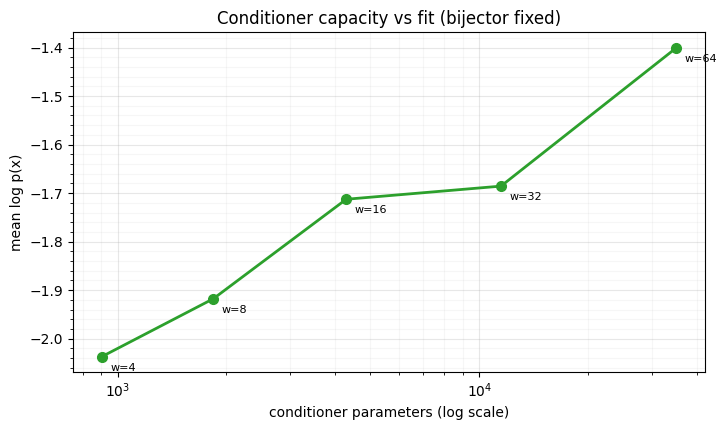

In [3]:
widths = [4, 8, 16, 32, 64]
sweep = {w: train(build(jr.key(0), width=w))[0] for w in widths}
pts = [(n_params(sweep[w]), logp(sweep[w])) for w in widths]
for w, (p, lp) in zip(widths, pts):
    print(f"  nn_width={w:3d}: {p:6d} params -> log p {lp:.3f}")

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot([p for p, _ in pts], [lp for _, lp in pts], "o-", color="tab:green", lw=2, ms=7)
for w, (p, lp) in zip(widths, pts):
    ax.annotate(f"w={w}", (p, lp), textcoords="offset points", xytext=(6, -10), fontsize=8)
ax.set(title="Conditioner capacity vs fit (bijector fixed)",
       xlabel="conditioner parameters (log scale)", ylabel="mean log p(x)", xscale="log")
style_ax(ax)
fig.tight_layout()

Likelihood climbs steadily with conditioner width — same bijector, same depth, the
only thing growing is the network that reads context. The gains taper in the middle
and pick up again with a much wider net: capacity is real but not free, the
trade-off the master list calls *parameter budget vs expressiveness*. (Depth is the
other knob; a **shared-MLP** conditioner — one trunk with per-coordinate heads — is
the parameter-efficient variant when the active half is high-dimensional.)

## 3. Output clamping for stability

The conditioner outputs include **log-scales**. Left unbounded, a single bad batch
can push a log-scale large, the coupling momentarily explodes or collapses volume,
and training spikes. `MixtureGaussianCDFCoupling`'s `log_scale_bound` clamps the
log-scale to $[-b, b]$ (via a smooth squash), a standard stabiliser. We train with
a tight bound and a loose one and watch the loss.

tight clamp (b=3) : final log p -1.628, peak training loss 3.5
loose clamp (b=50): final log p -1.906, peak training loss 17.8


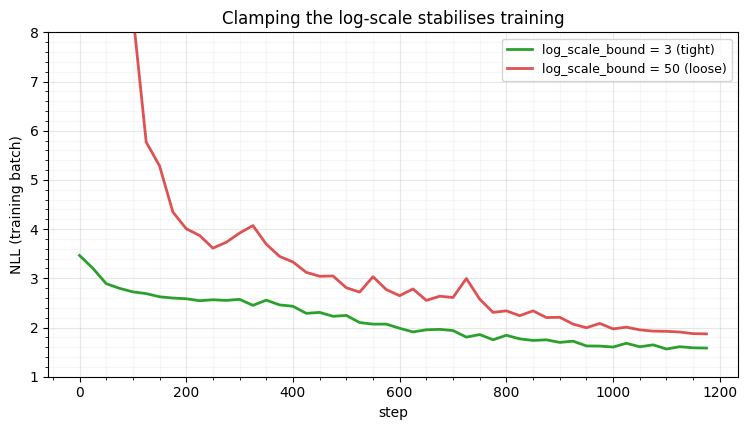

In [4]:
tight, traj_tight = train(build(jr.key(0), log_scale_bound=3.0), track=True)
loose, traj_loose = train(build(jr.key(0), log_scale_bound=50.0), track=True)
print(f"tight clamp (b=3) : final log p {logp(tight):.3f}, peak training loss {traj_tight.max():.1f}")
print(f"loose clamp (b=50): final log p {logp(loose):.3f}, peak training loss {traj_loose.max():.1f}")

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(np.arange(len(traj_tight)) * 25, traj_tight, color="tab:green", lw=2, label="log_scale_bound = 3 (tight)")
ax.plot(np.arange(len(traj_loose)) * 25, traj_loose, color="tab:red", lw=2, alpha=0.8, label="log_scale_bound = 50 (loose)")
ax.set(title="Clamping the log-scale stabilises training",
       xlabel="step", ylabel="NLL (training batch)", ylim=(1, 8))
ax.legend(fontsize=9); style_ax(ax)
fig.tight_layout()

The tight clamp trains smoothly to a better optimum; the loose one spikes (its
log-scale wanders far enough to momentarily wreck the likelihood) and settles
higher. Even with gradient clipping in the optimiser, bounding the *parameterised*
log-scale is a cheap, effective second line of defence — and the reason coupling
layers expose `log_scale_bound`.

## 4. The conditioner menu — where Parts 11–13 plug in

Everything above used an MLP because the data is an unstructured 2-D vector. The
coupling contract does not care what $c_\phi$ is, so the conditioner is the natural
place to inject **domain structure**:

| data | conditioner | where |
|---|---|---|
| vectors | MLP / shared-MLP / ResNet | here (5.C) |
| images | CNN (preserves spatial dims) | Part 12 |
| sequences | RNN / Transformer / Mamba (causal) | Part 11 |
| graphs | message-passing GNN | Part 5 (research) |
| symmetric domains | equivariant network | Parts 12–13 |

Same triangular-Jacobian, free-log-det coupling; only the network reading $x_A$
changes. That modularity is why coupling flows generalise across modalities.

## Recap

| knob | effect |
|---|---|
| conditioner **width / depth** | capacity → expressiveness (diminishing returns) |
| **shared-MLP** trunk + heads | parameter-efficient for high-dim active halves |
| **`log_scale_bound`** | clamps log-scale → stable training, better optimum |
| conditioner **architecture** | injects modality structure (CNN / RNN / GNN / equivariant) |

The bijector sets *what shape* a coordinate map can take; the conditioner sets *how
richly* it reacts to the rest of the data — and it is the part you swap per domain.

**Next up.** A coupling layer only transforms half the coordinates, so which half,
and how the halves alternate, matters. [03 — Mask design](03_mask_design.ipynb)
covers checkerboard / channel-wise / learned masks and how stacking them gives
every coordinate both roles.